In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from utils import CLEAN_DATA_PATH, encode_sequence
from sklearn.model_selection import train_test_split

In [2]:
dataframe = pd.read_csv(CLEAN_DATA_PATH)

In [3]:
X = np.array(dataframe['sequence'].apply(encode_sequence).tolist())
y = dataframe['class'].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2392, 480), Test: (798, 480)


In [7]:
C_values = [2**i for i in range(-5, 8, 2)]
gamma_values = [2**i for i in range(-15, 4, 2)]

print("C values:", C_values)
print("Gamma values:", gamma_values)
print(f"Total combos: {len(C_values) * len(gamma_values)}")

C values: [0.03125, 0.125, 0.5, 2, 8, 32, 128]
Gamma values: [3.0517578125e-05, 0.0001220703125, 0.00048828125, 0.001953125, 0.0078125, 0.03125, 0.125, 0.5, 2, 8]
Total combos: 70


In [8]:
param_grid = {
    'C': C_values,
    'gamma': gamma_values
}

svm = SVC(kernel='rbf', random_state=42)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

In [9]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.03125, 0.125, ...], 'gamma': [3.0517578125e-05, 0.0001220703125, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.5


In [10]:
y_pred = grid_search.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9586

Classification Report:
              precision    recall  f1-score   support

          EI       0.94      0.95      0.95       192
          IE       0.94      0.92      0.93       192
           N       0.98      0.98      0.98       414

    accuracy                           0.96       798
   macro avg       0.95      0.95      0.95       798
weighted avg       0.96      0.96      0.96       798



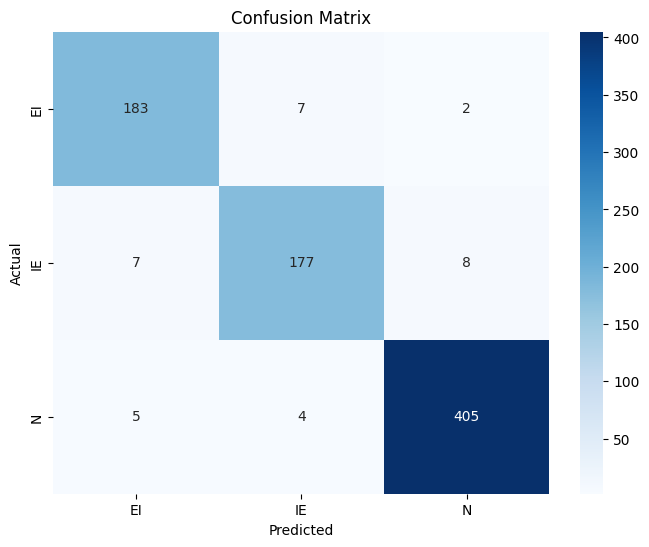

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=['EI', 'IE', 'N'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['EI', 'IE', 'N'],
            yticklabels=['EI', 'IE', 'N'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

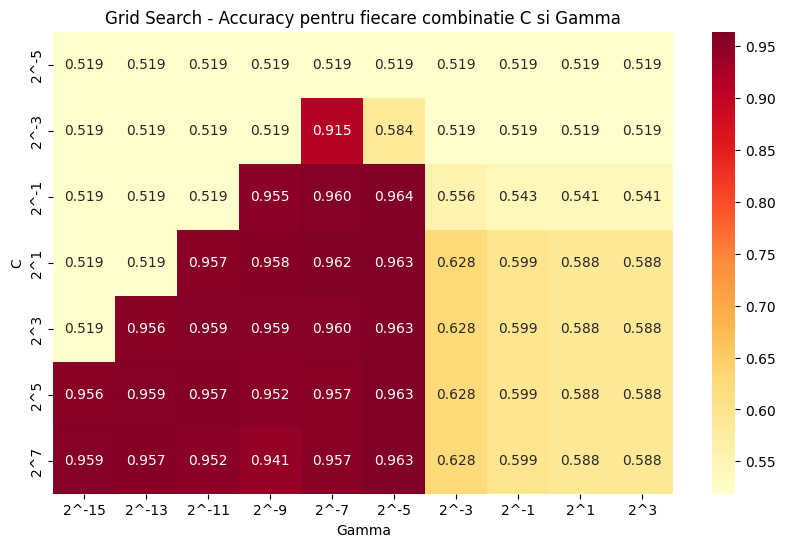

In [12]:
results = pd.DataFrame(grid_search.cv_results_)
scores = results['mean_test_score'].values.reshape(len(C_values), len(gamma_values))

plt.figure(figsize=(10, 6))
sns.heatmap(scores, 
            xticklabels=[f'2^{i}' for i in range(-15, 4, 2)],
            yticklabels=[f'2^{i}' for i in range(-5, 8, 2)],
            annot=True, fmt='.3f',
            cmap='YlOrRd')
plt.title('Grid Search - Accuracy pentru fiecare combinatie C si Gamma')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()